# Ferricyanide (Fe³⁺) reference — aggregate of runs 9 + 10

**Reads already-processed XSpect results from disk — nothing is re-run.**
Sources: `results/runs_9_static_xes.h5`, `results/runs_10_static_xes.h5`.

Builds a single ferric ferricyanide reference spectrum for Fe Kα and Fe Kβ
by aggregating runs 9 and 10, then saves it for use as the Fe(III) standard
in speciation notebooks.

Analysis windows:

| Line | Window (eV) |
|------|-------------|
| Fe Kα | 6380 – 6410 |
| Fe Kβ | 7031 – 7075 |

Processing:
1. **Load** runs 9 and 10 (each may have a slightly different energy axis).
2. **Aggregate** — interpolate each run onto a common grid within the window
   and sum (photon-weighted), giving the combined reference spectrum.
3. **Basic baseline** — subtract the per-line minimum so the floor sits at 0
   (no polynomial fitting).
4. **Normalize** — area-normalize.
5. **Save** — write to `results/ferricyanide_ferric_reference.h5`.

In [1]:
import os
import h5py
import numpy as np
import matplotlib.pyplot as plt

HERE    = os.path.dirname(os.path.abspath('__file__'))
RESULTS = os.path.join(HERE, 'results')

RUNS    = [9, 10]                 # runs to aggregate into the ferric reference
KA_WIN  = (6380.0, 6410.0)
KB_WIN  = (7031.0, 7075.0)
N_GRID  = 400                     # points on the common interpolation grid

def load_run(run):
    """Return (ka_energy, ka_spec, kb_energy, kb_spec, total_shots) for a run."""
    path = os.path.join(RESULTS, f'runs_{run}_static_xes.h5')
    if not os.path.exists(path):
        raise FileNotFoundError(
            f'{path} not found. Run {run} must be processed through the XSpect '
            f'pipeline + Save cell before it can be aggregated here.')
    with h5py.File(path, 'r') as fh:
        ke = fh['kalpha_energy'][:]
        be = fh['kbeta_energy'][:]
        rk = f'run_{run}' if f'run_{run}' in fh else next(k for k in fh if k.startswith('run_'))
        ka = np.asarray(fh[f'{rk}/kalpha'][:], dtype=float)
        kb = np.asarray(fh[f'{rk}/kbeta'][:], dtype=float)
        n  = int(fh[rk].attrs.get('total_shots', 0))
    return ke, ka, be, kb, n

data = {}
for run in RUNS:
    ke, ka, be, kb, n = load_run(run)
    data[run] = dict(ka_e=ke, ka=ka, kb_e=be, kb=kb, shots=n)
    print(f'run {run}: {n} shots | Kα axis {ke.min():.1f}–{ke.max():.1f} | '
          f'Kβ axis {be.min():.1f}–{be.max():.1f} | Kα sum {ka.sum():.0f} Kβ sum {kb.sum():.0f}')

run 9: 36021 shots | Kα axis 6377.3–6452.2 | Kβ axis 6993.2–7075.3 | Kα sum 1247013 Kβ sum 472990
run 10: 35744 shots | Kα axis 6377.3–6452.2 | Kβ axis 6993.2–7075.3 | Kα sum 1421416 Kβ sum 545623


## 1. Aggregate runs onto a common grid

Runs 9 and 10 may sit on slightly different energy axes (geometry/ROI can
drift between runs). Each run is interpolated onto a shared grid spanning the
analysis window, then the interpolated spectra are **summed** (photon-weighted
— raw ADU, no per-run normalization) to form the aggregate reference.

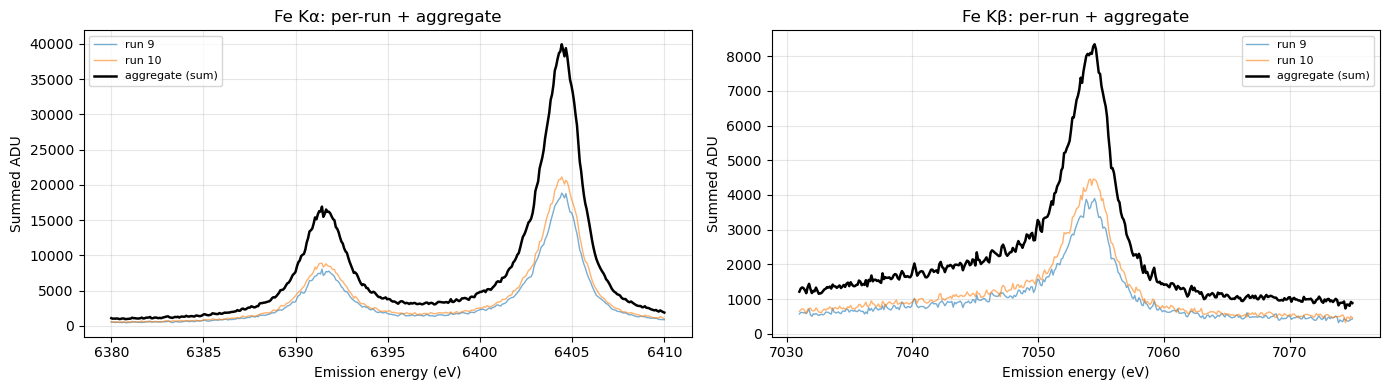

Aggregate Kα integrated: 220127 ADU·eV
Aggregate Kβ integrated: 94975 ADU·eV


In [2]:
def aggregate(line, win):
    """Interpolate each run's spectrum onto a common grid in `win` and sum."""
    grid = np.linspace(win[0], win[1], N_GRID)
    total = np.zeros_like(grid)
    per_run = {}
    for run in RUNS:
        e = data[run][f'{line}_e']
        s = data[run][line]
        # only interpolate within each run's measured range; outside -> 0
        y = np.interp(grid, e, s, left=0.0, right=0.0)
        per_run[run] = y
        total += y
    return grid, total, per_run

ka_grid, ka_agg, ka_per = aggregate('ka', KA_WIN)
kb_grid, kb_agg, kb_per = aggregate('kb', KB_WIN)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, grid, agg, per, lbl in [
    (axes[0], ka_grid, ka_agg, ka_per, 'Fe Kα'),
    (axes[1], kb_grid, kb_agg, kb_per, 'Fe Kβ'),
]:
    for run, y in per.items():
        ax.plot(grid, y, lw=1.0, alpha=0.6, label=f'run {run}')
    ax.plot(grid, agg, 'k-', lw=1.8, label='aggregate (sum)')
    ax.set_title(f'{lbl}: per-run + aggregate')
    ax.set_xlabel('Emission energy (eV)'); ax.set_ylabel('Summed ADU')
    ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f'Aggregate Kα integrated: {np.trapz(ka_agg, ka_grid):.0f} ADU·eV')
print(f'Aggregate Kβ integrated: {np.trapz(kb_agg, kb_grid):.0f} ADU·eV')

## 2. Basic baseline — subtract the minimum

No polynomial fitting. Simply shift each aggregate spectrum down by its
minimum value in the window so the floor sits at zero. This preserves peak
shape exactly while removing a flat offset.

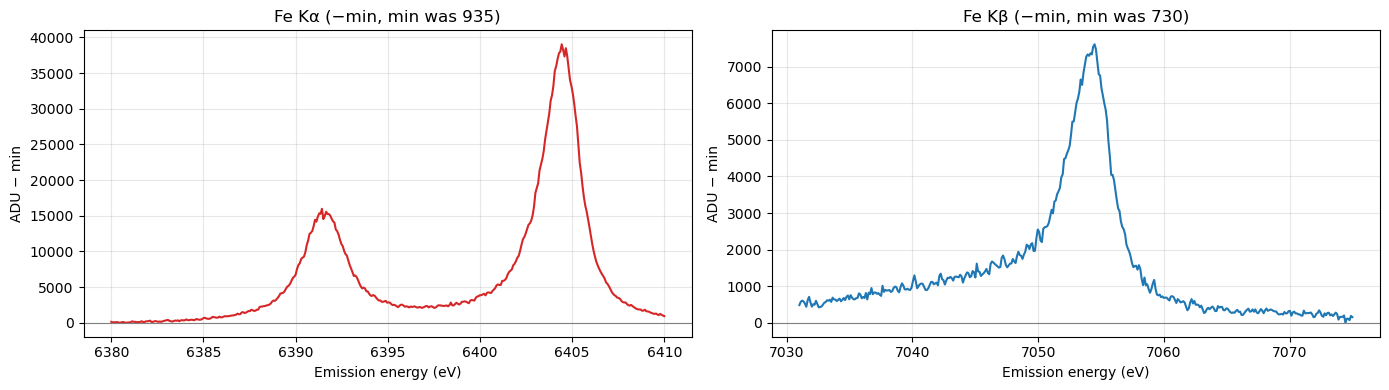

Kα: subtracted floor 935 ADU  (min now 0.0)
Kβ: subtracted floor 730 ADU  (min now 0.0)


In [3]:
ka_min = np.nanmin(ka_agg)
kb_min = np.nanmin(kb_agg)
ka_sub = ka_agg - ka_min
kb_sub = kb_agg - kb_min

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(ka_grid, ka_sub, color='C3'); axes[0].set_title(f'Fe Kα (−min, min was {ka_min:.0f})')
axes[1].plot(kb_grid, kb_sub, color='C0'); axes[1].set_title(f'Fe Kβ (−min, min was {kb_min:.0f})')
for ax in axes:
    ax.axhline(0, color='gray', lw=0.8)
    ax.set_xlabel('Emission energy (eV)'); ax.set_ylabel('ADU − min'); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f'Kα: subtracted floor {ka_min:.0f} ADU  (min now {ka_sub.min():.1f})')
print(f'Kβ: subtracted floor {kb_min:.0f} ADU  (min now {kb_sub.min():.1f})')

## 3. Normalize

Area-normalize the min-subtracted aggregate so ∫ = 1. This is the final
ferric ferricyanide reference for each line.

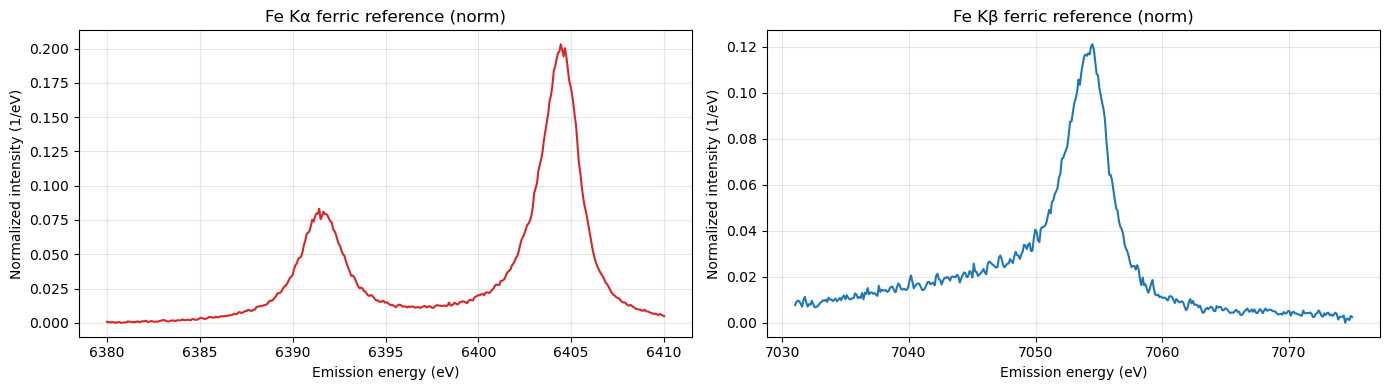

Kα peak @ 6404.44 eV;  area before norm 192074.3
Kβ peak @ 7054.49 eV;  area before norm 62876.0


In [4]:
def area_normalize(energy, spec):
    area = np.trapz(spec, energy)
    return (spec / area if area > 0 else spec), area

ka_ref, ka_area = area_normalize(ka_grid, ka_sub)
kb_ref, kb_area = area_normalize(kb_grid, kb_sub)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(ka_grid, ka_ref, color='C3'); axes[0].set_title('Fe Kα ferric reference (norm)')
axes[1].plot(kb_grid, kb_ref, color='C0'); axes[1].set_title('Fe Kβ ferric reference (norm)')
for ax in axes:
    ax.set_xlabel('Emission energy (eV)'); ax.set_ylabel('Normalized intensity (1/eV)')
    ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f'Kα peak @ {ka_grid[np.argmax(ka_ref)]:.2f} eV;  area before norm {ka_area:.1f}')
print(f'Kβ peak @ {kb_grid[np.argmax(kb_ref)]:.2f} eV;  area before norm {kb_area:.1f}')

## 4. Save ferric ferricyanide reference

Writes the aggregate reference (energy grid, min-subtracted, and normalized
spectra) to `results/ferricyanide_ferric_reference.h5` so speciation
notebooks can load it as the Fe(III) standard.

In [5]:
out_file = os.path.join(RESULTS, 'ferricyanide_ferric_reference.h5')
with h5py.File(out_file, 'w') as fh:
    fh.attrs['label']        = 'ferricyanide_ferric'
    fh.attrs['runs']         = RUNS
    fh.attrs['total_shots']  = sum(data[r]['shots'] for r in RUNS)
    fh.attrs['ka_window_eV'] = KA_WIN
    fh.attrs['kb_window_eV'] = KB_WIN
    fh.attrs['baseline']     = 'minimum-subtracted'
    for line, grid, agg, sub, ref in [
        ('kalpha', ka_grid, ka_agg, ka_sub, ka_ref),
        ('kbeta',  kb_grid, kb_agg, kb_sub, kb_ref),
    ]:
        g = fh.create_group(line)
        g['energy']      = grid
        g['aggregate']   = agg    # summed raw ADU
        g['min_sub']     = sub    # after minimum subtraction
        g['normalized']  = ref    # area-normalized reference
print(f'Wrote {out_file}')
print(f'Aggregated runs {RUNS}, {sum(data[r]["shots"] for r in RUNS)} total shots.')

Wrote /sdf/data/lcls/ds/mfx/mfx100895324/results/lbgee/XSpect/experiments/mfx102101026/results/ferricyanide_ferric_reference.h5
Aggregated runs [9, 10], 71765 total shots.
